In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import cwt
from ssqueezepy.visuals import plot
from scipy.io import loadmat
import sys
import os

sys.path.append(os.path.abspath("/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/wavelets"))

from plot_cwt import plot_cwt

In [2]:
data = loadmat('/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/bbm_tide2crittry.mat')
B1s = data['B1s']

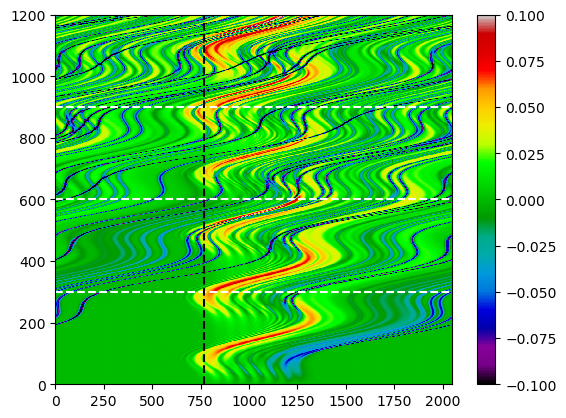

In [3]:
fig, ax = plt.subplots()
c1 = ax.pcolormesh(B1s.T, shading='flat', cmap='nipy_spectral', vmin=-0.1, vmax=0.1)
plt.colorbar(c1)

ax.plot([1, 2048],[300, 300],'w--')
ax.plot([1, 2048],[600, 600],'w--')
ax.plot([1, 2048],[900, 900],'w--')
ax.plot([1, 2048],[1200, 1200],'w--')
ax.plot([768, 768],[1, 1200],'k--')

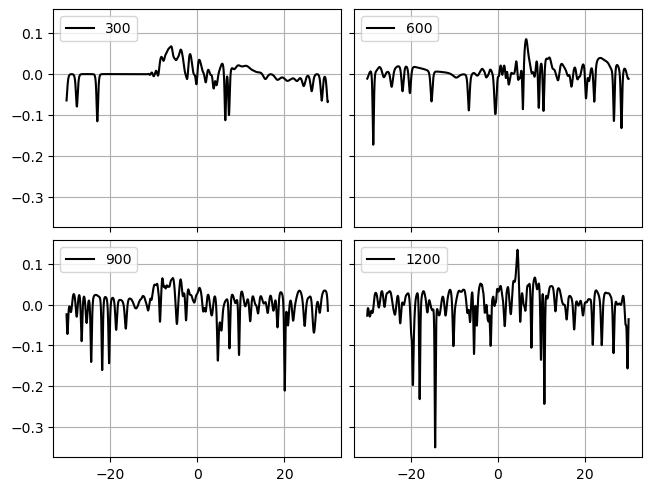

In [4]:
fig, axs = plt.subplots(
    nrows=2, ncols=2, layout='constrained',
    sharex=True, sharey=True
)

ens = [300, 600, 900, 1200]

for ii in range(len(ens)):
    en = ens[ii]
    row = ii // 2
    col = ii % 2

    axs[row, col].plot(
        data['x'][0, :],
        data['B1s'][:, en - 1],
        'k',
        label=str(en)
    )
    axs[row, col].legend(loc='upper left')
    axs[row, col].grid()

In [5]:
print('Space dim has length', len(data['x'][0,:]))
print('data have shape', data['B1s'].shape)

Space dim has length 2048
data have shape (2048, 1200)


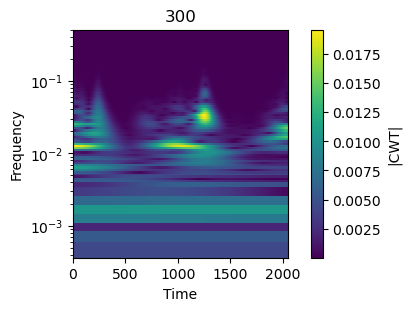

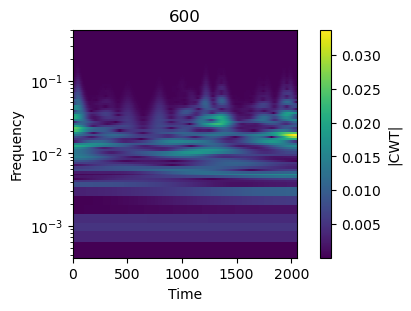

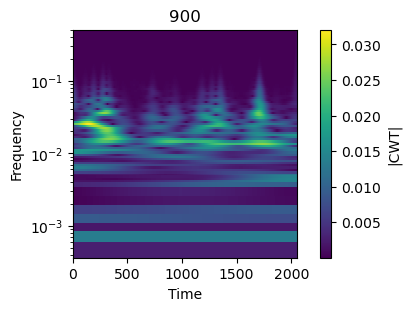

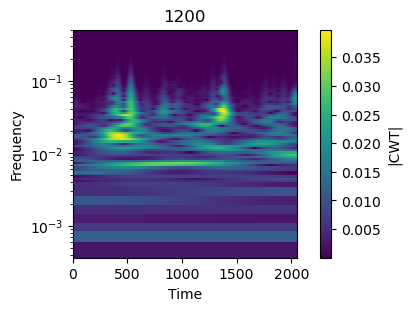

In [8]:
# Make cwt for each
N = len(data['B1s'][:, en-1])
t = np.arange(N)
for ii in range(len(ens)):
    en = ens[ii]
    row = ii // 2
    col = ii % 2
    Wx, period = plot_cwt(
        data['B1s'][:, en-1], # np.vstack((data['B1s'][:, en-1], data['B1s'][:, en-1])), 
        'gmw', t=t,
        nv=10, N=N, 
        title=str(en)
    )

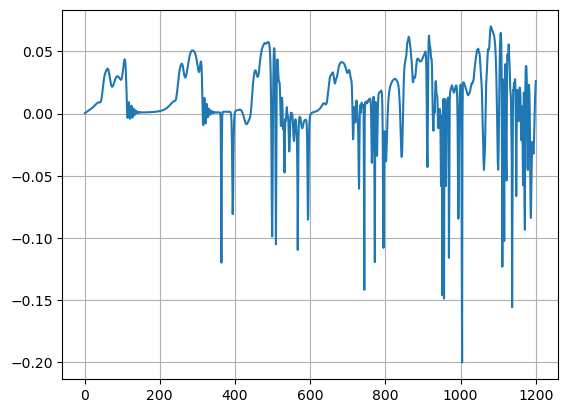

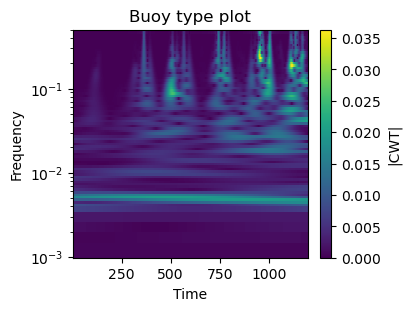

In [9]:
# wavelet for buoy type plot
x = data['B1s'][768, :]
t = np.arange(1, 1201)
fig, ax = plt.subplots()
ax.plot(t, x)
ax.grid()

Wx, period = plot_cwt(
    x, 'gmw', t=t, nv=10, N=N, 
    title='Buoy type plot'
)